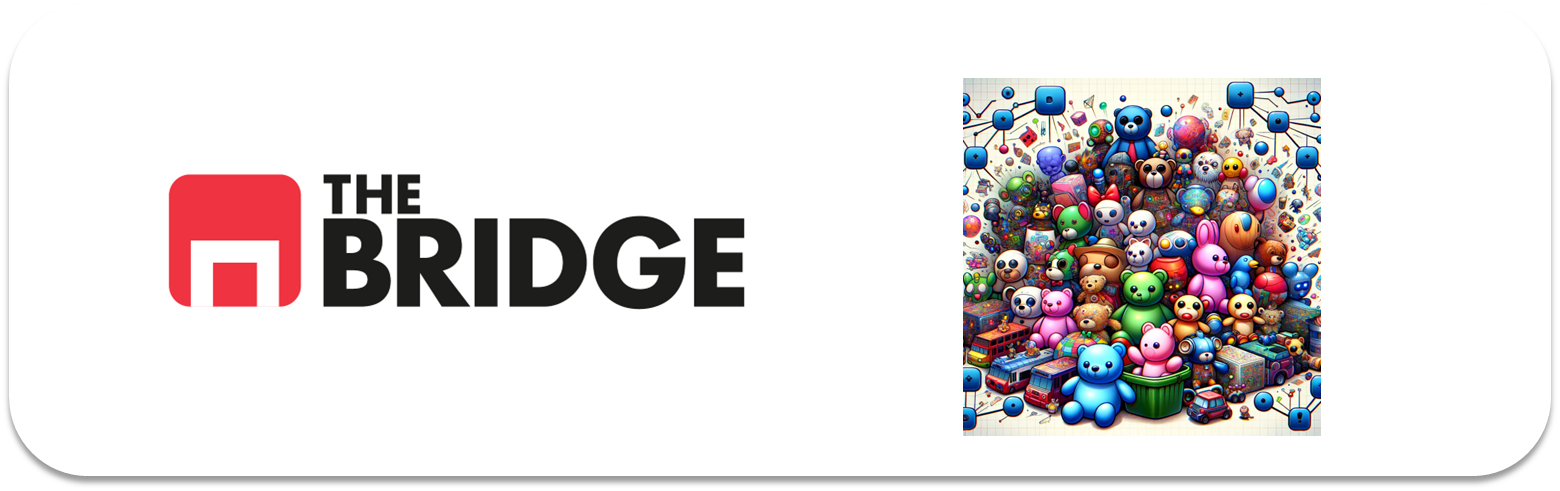

# PRÁCTICA OBLIGATORIA
## **DBSCAN y Clustering Jerárquico**

* La práctica obligatoria de esta unidad consiste en un ejercicio de modelado no supervisado aplicado a clustering jerárquico y no jerárquico. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo.
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso.

Importa los paquetes y módulos que necesites a lo largo del notebook

In [316]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

### Parte I: Modelado

#### Descripción del problema

En una planta de experimentación con nuevas bebidas energéticas están trabajando con diferentes mezclas de componentes para obtener posibles variedades de su producto estrella "NonstopU". El problema es que la fabricación de cada "prototipo" conlleva demasiado tiempo y las pruebas de sabores y de propiedades "non-stop" antisueño y antifatiga son costosas.

En ese sentido quieren construir algún sistema de segmentación previa de mezclas sin probarlas solo indicando las cantidades de cada componente de la bebida. Tienen datos pero desgraciadamente de mezclas anteriores con diferentes medidas pero que por temas presupuestarios y de prioridad no se hicieron test con usuarios y potenciales clientes, es decir no tienen un target de capacidad antifatiga o de preferncia del usuario que puedas servirles para construir un clasificador clásico como han hecho otras veces.

Han acudido a vosotros con la necesida de encontrar ese segmentador de posibles bebidas y con los datos de las mezclas no probadas anteriores por ver si vostros podéis ayudarles a encontrar algún tipo de segmentación que luego ello se encargarían de interpretar. No es requisito obligatorio pero les gustaría también poder establecer algún tipo de relación entre las segmentaciones (tipo cuales segmentos se "parecerían" más entre sí)

**NOTA ORIENTATIVA:** Los químicos no esperan que haya menos de 3 segmentos ni más de 5.

**NOTA OPERATIVA:** El dataset con los datos que nos han dado los químicos está en "./data/empowering_drinks.csv"

**Se pide:** Construir al menos dos algoritmos de clustering (DBSCAN debe ser uno de ellos y el otro debería estar claro cual deberíamos usar dado el enunciado). Compararlos brevemente aunque sea meramente especulativo (¿Por qué es espculativo?)

**Se recomienda:** Visualizar las features dos a dos para escoger las mejores, no necesariamente hay que usar todas, ni tampoco quedarse en dos. Probar diferentes hiperparámetros en función de la nota orientativa y explicar porqué se han escogido los que finalmente se hayan escogido.

Recuerda que el proceso es similar a lo que vimos en el otro tipo de aprendizaje:
1. Entender el problema
2. Cargar datos, visualizar.
3. MiniEDA: Selección de features
4. Tratamiento de Features.
5. Selección de modelos, selección de hiperparámetros
6. Entrenamiento, visualización de resultados.
7. Discusión de los mismos

#### Cargar datos, visualizar

In [317]:
df_empowering_drinks = pd.read_csv(
	"./data/empowering_drinks.csv",
	sep="|"
)
df_empowering_drinks.head()

,Azúcares,Vitamínas del grupo B,Cafeína,Ácido Cítrico,Taurina
0,1.518613,0.232053,1.034819,1.013009,0.251717
1,0.246290,-0.827996,0.733629,0.965242,-0.293321
2,0.196879,1.109334,1.215533,1.395148,0.269020
3,1.691550,0.487926,1.466525,2.334574,1.186068
4,0.295700,1.840403,0.663351,-0.037874,-0.319276


In [318]:
df_empowering_drinks.describe()

,Azúcares,Vitamínas del grupo B,Cafeína,Ácido Cítrico,Taurina
count,153.000000,153.000000,153.000000,153.000000,153.000000
mean,0.019231,0.037273,0.041057,0.080022,-0.044088
std,1.026182,0.995984,1.040928,1.009450,0.934399
min,-2.434235,-3.679162,-1.695971,-1.493188,-1.634288
25%,-0.816038,-0.499016,-1.043392,-0.738463,-0.799428
50%,0.061000,-0.023821,0.211566,-0.165254,-0.154899
75%,0.876275,0.707247,0.894264,0.917474,0.493956
max,2.259772,3.156325,3.062832,2.971473,2.431870


En una primer aproximación podemos notar que los datos se encuentran escalados

In [319]:
df_empowering_drinks.info()

<class 'pandas.DataFrame'>
RangeIndex: 153 entries, 0 to 152
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Azúcares               153 non-null    float64
 1   Vitamínas del grupo B  153 non-null    float64
 2   Cafeína                153 non-null    float64
 3   Ácido Cítrico          153 non-null    float64
 4   Taurina                153 non-null    float64
dtypes: float64(5)
memory usage: 6.1 KB


También, podemos observar que no existen valores nulos.

#### MiniEDA: Selección de features

Hacemos un `pairplot` para poder visualizar como se relacionan las variables unas con otras con la intención de descrubir cuales de ellas nos permitiría generar clusters.

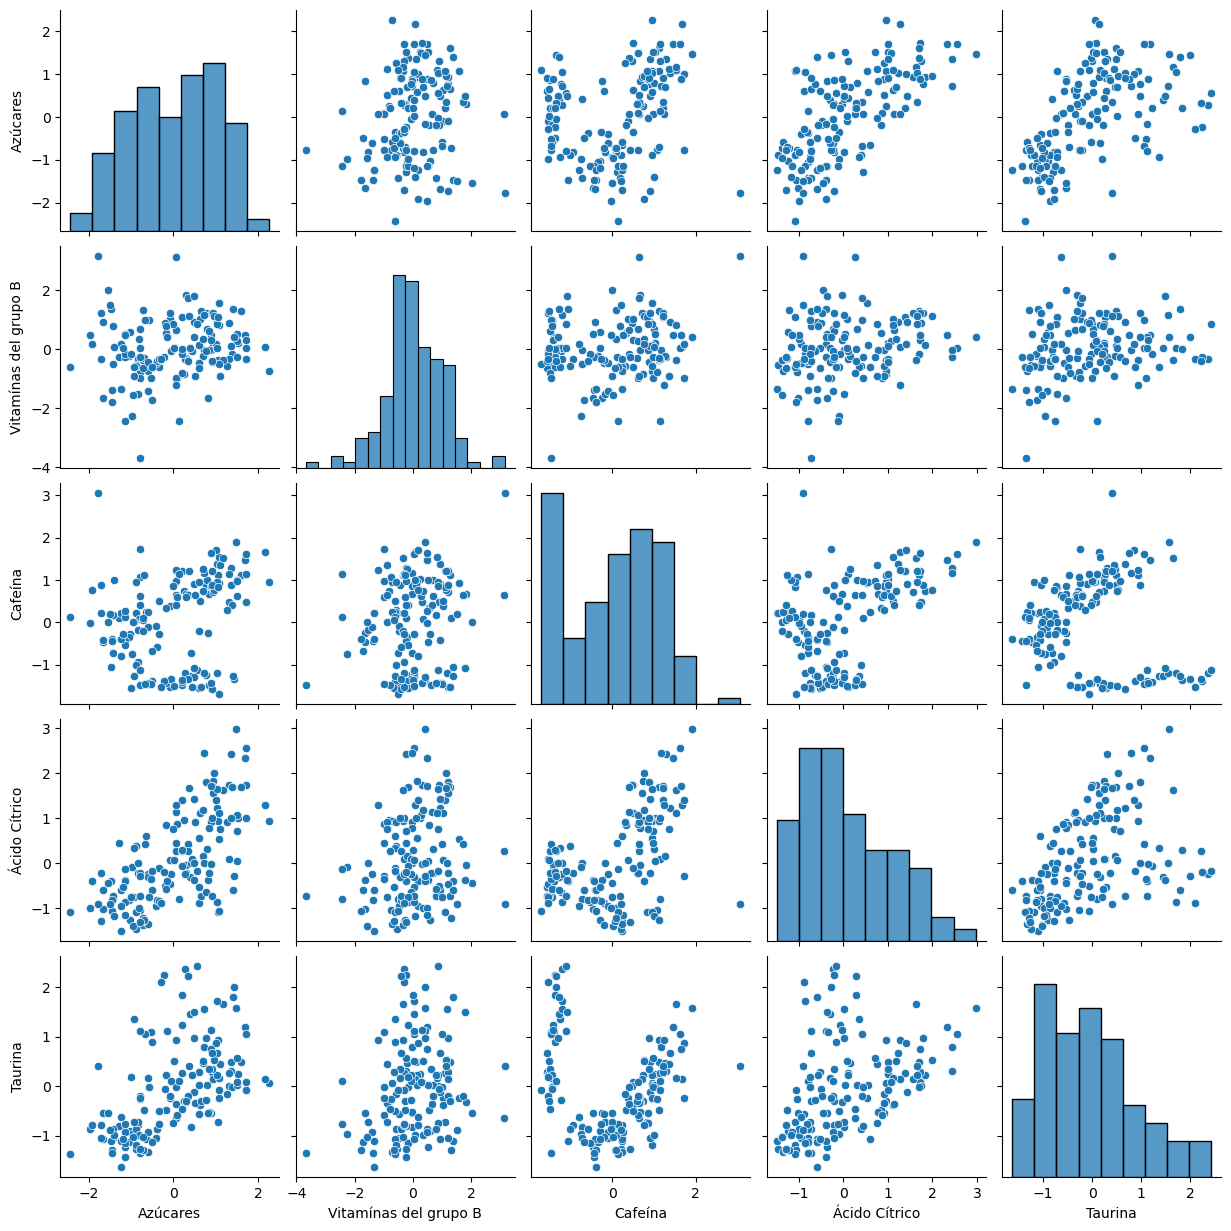

In [320]:
sns.pairplot(df_empowering_drinks)

Analizando el `pairplot` podemos observar que la variable `Cafeína` con `Taurina` es la que nos permite visualizar algunos cluters.

In [321]:
df_empowering_drinks.head()

,Azúcares,Vitamínas del grupo B,Cafeína,Ácido Cítrico,Taurina
0,1.518613,0.232053,1.034819,1.013009,0.251717
1,0.246290,-0.827996,0.733629,0.965242,-0.293321
2,0.196879,1.109334,1.215533,1.395148,0.269020
3,1.691550,0.487926,1.466525,2.334574,1.186068
4,0.295700,1.840403,0.663351,-0.037874,-0.319276


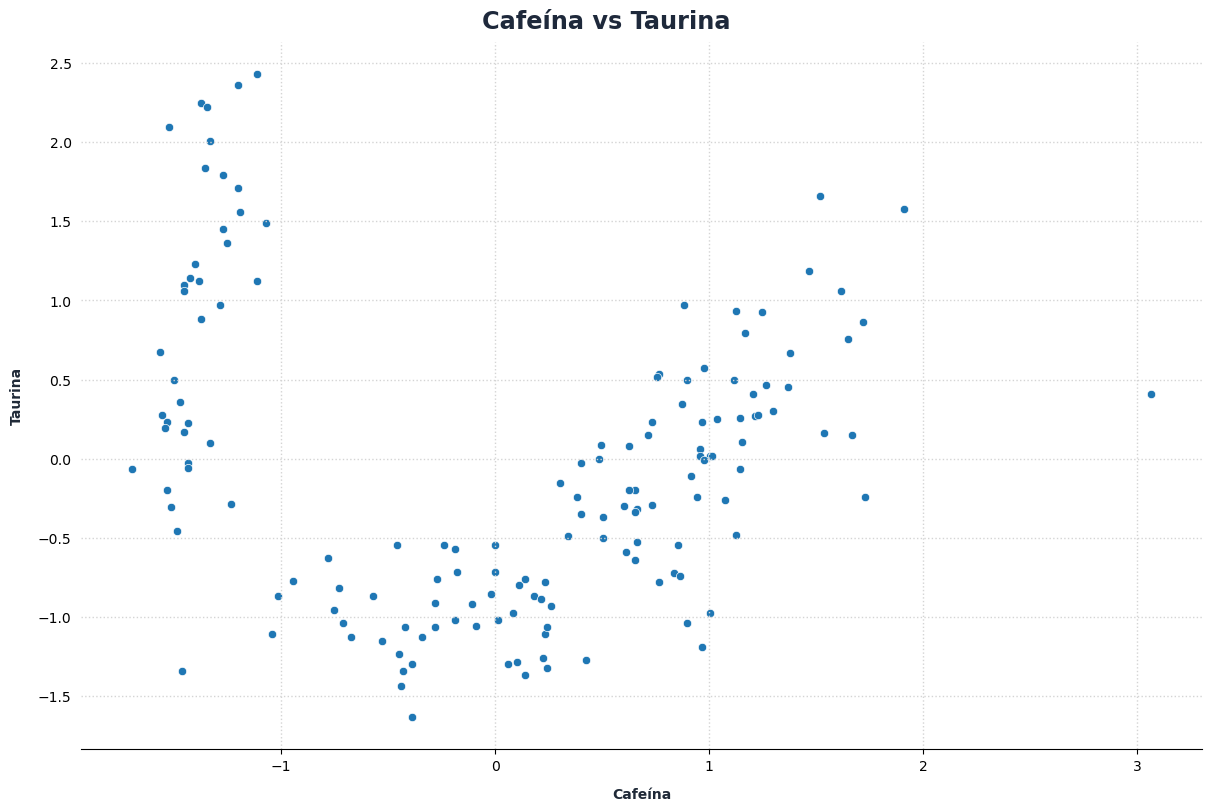

In [322]:
fig, ax = plt.subplots(figsize=(12, 8), layout="constrained")
font_config = {
	"fig_title": {
		"family": "sans-serif",
		"size": "xx-large",
		"weight": "black"
	},
	"fig_text": {
		"family": "sans-serif",
		"size": "x-large",
		"weight": "black"
	},
	"plot_title": {
		"family": "sans-serif",
		"size": "large",
		"weight": "heavy"
	},
	"plot_label": {
		"color": "#1F2937",
		"family": "sans-serif",
		"size": "medium",
		"weight": "bold"
	}
}

fig.suptitle(
	f"Cafeína vs Taurina",
	color="#1E293B",
	fontproperties=font_config["fig_title"]
)
sns.scatterplot(
	x="Cafeína",
	y="Taurina",
	data=df_empowering_drinks
)
ax.set_xlabel(
	"Cafeína",
	fontdict=font_config["plot_label"],
	labelpad=10
)
ax.set_ylabel(
	"Taurina",
	fontdict=font_config["plot_label"],
	labelpad=10
)
ax.tick_params(axis="y", width=0)
ax.grid(axis="both", color="#D4D4D4", linestyle="dotted", linewidth=1)
ax.spines[["left", "right", "top"]].set_visible(False)
plt.show()

#### Tratamiento de Features

Como hemos visto, las variables se encuentran estandarizadas.

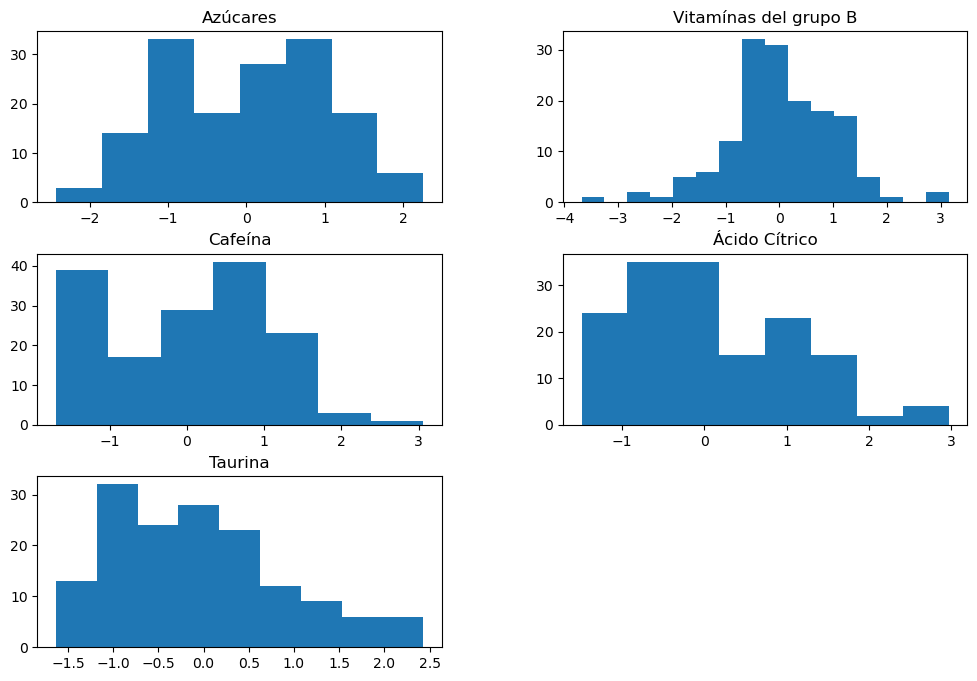

In [323]:
df_empowering_drinks.hist(
	figsize=(12, 8),
	bins="fd",
	grid=False
);

#### Selección de modelos, selección de hiperparámetros

##### DBSCAN

In [324]:
from sklearn.cluster import DBSCAN

Realizamos una primer aproximación antes de pasar a evaluar los mejores parámetros para nuestro `DBSCAN`. Entrenamos nuestro modelo, teniendo en cuenta que la distancia entre los puntos. Dejamos los parámetros por defecto, pero ajustamos la distancia a ojo.

In [325]:
columns = ["Cafeína", "Taurina"]

dbscan = DBSCAN(eps=.3)
dbscan.fit(df_empowering_drinks[columns])
labels = dbscan.labels_
print("Clusters localizados: ", np.unique(labels))

Clusters localizados:  [-1  0  1  2  3]


Como vemos, encontramos cuatro clusters (el label -1 representa anomalías).

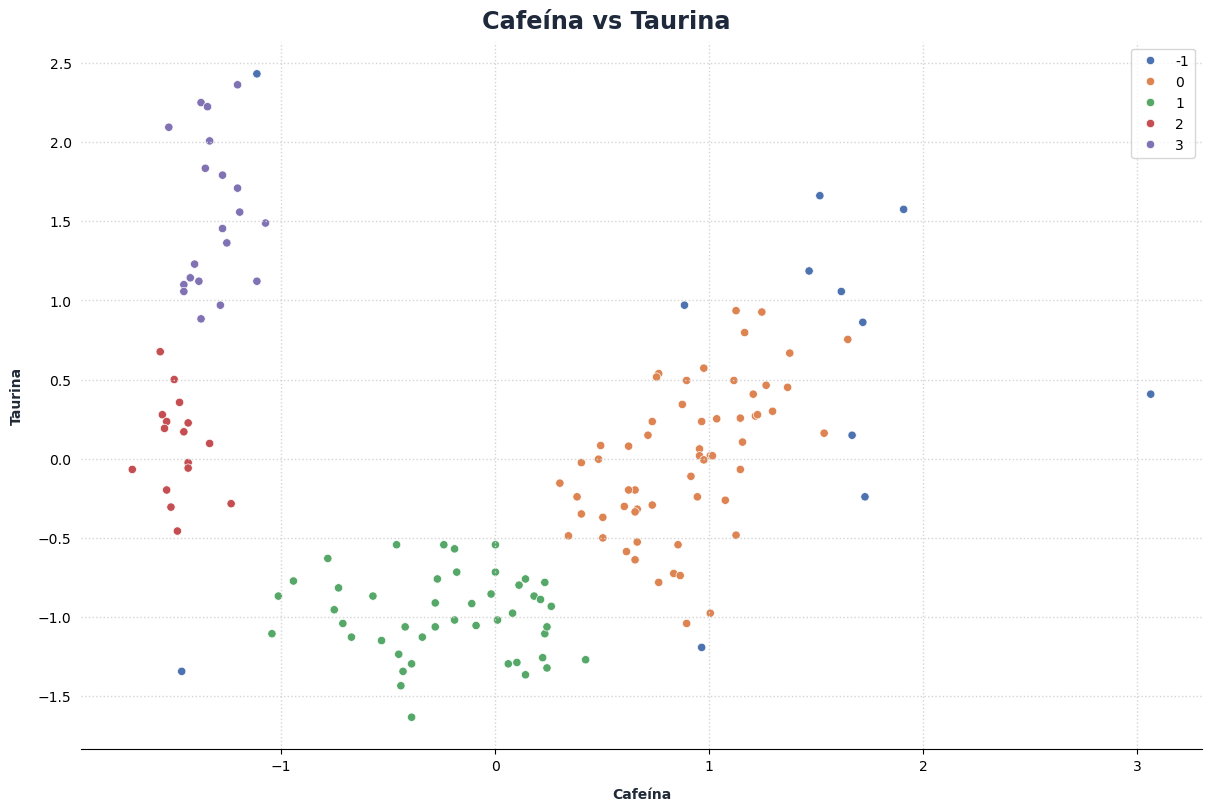

In [326]:
fig, ax = plt.subplots(figsize=(12, 8), layout="constrained")

fig.suptitle(
	f"Cafeína vs Taurina",
	color="#1E293B",
	fontproperties=font_config["fig_title"]
)
sns.scatterplot(
	x=df_empowering_drinks["Cafeína"],
	y=df_empowering_drinks["Taurina"],
	hue=labels,
	palette="deep"
)
ax.set_xlabel(
	"Cafeína",
	fontdict=font_config["plot_label"],
	labelpad=10
)
ax.set_ylabel(
	"Taurina",
	fontdict=font_config["plot_label"],
	labelpad=10
)
ax.tick_params(axis="y", width=0)
ax.grid(axis="both", color="#D4D4D4", linestyle="dotted", linewidth=1)
ax.spines[["left", "right", "top"]].set_visible(False)
plt.show()

In [327]:
attempts = {}

distances = np.linspace(.1, 1, 20)
for _, min_samples in enumerate(range(3, 10, 1)):
	outliers = []
	for eps in distances:
		dbscan = DBSCAN(eps=eps, min_samples=min_samples)
		dbscan.fit(df_empowering_drinks[columns])

		percentage = np.sum(dbscan.labels_ == -1) / len(dbscan.labels_)
		outliers.append(percentage)

	attempts[min_samples] = {
		"outliers": outliers.copy(),
	}

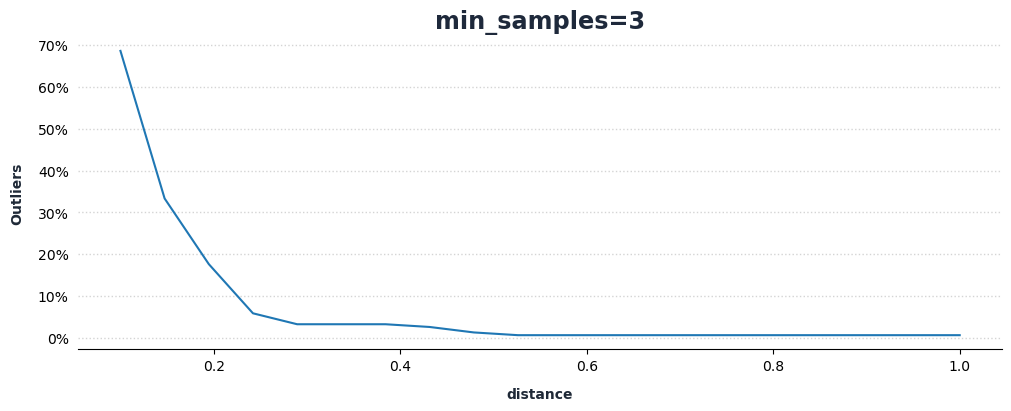

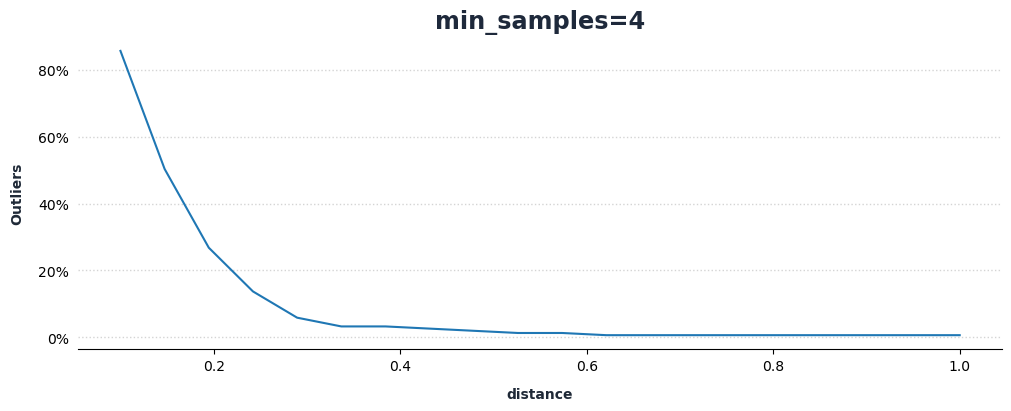

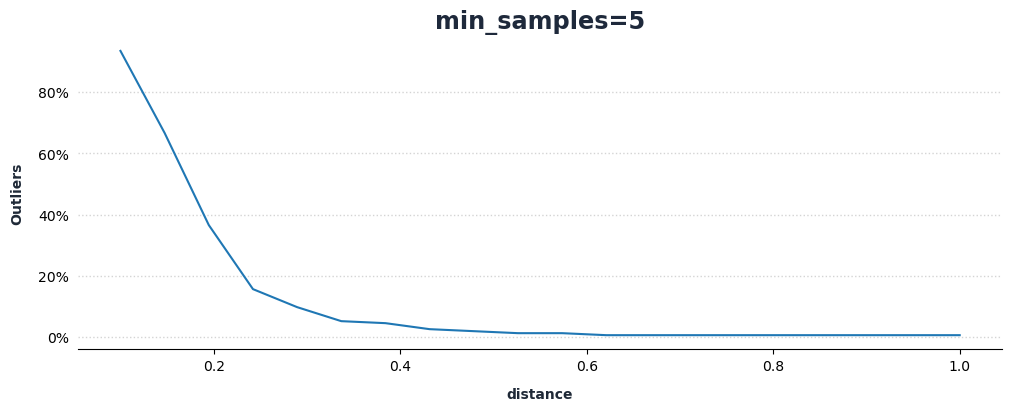

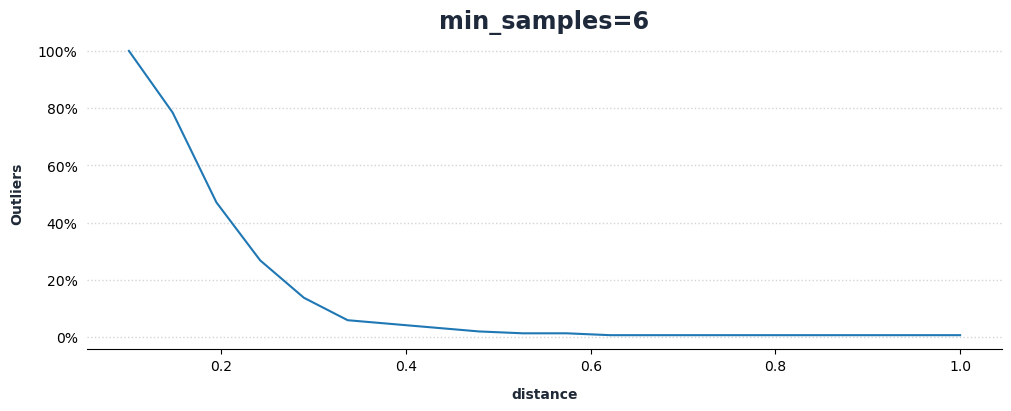

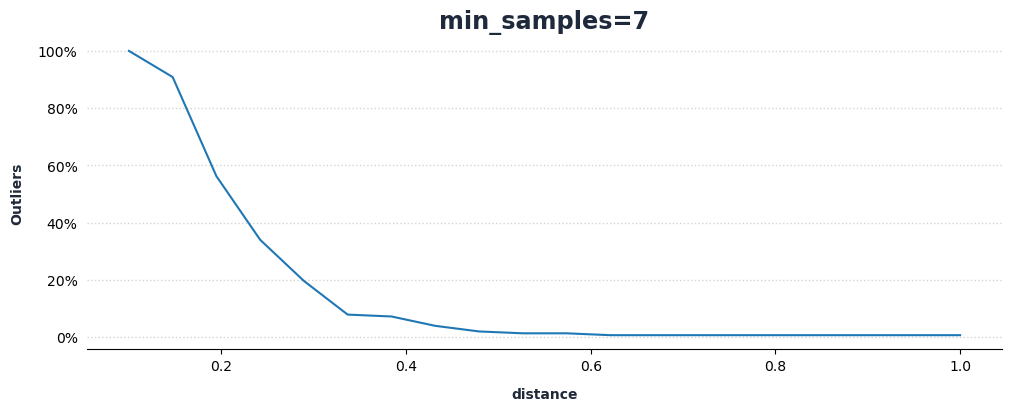

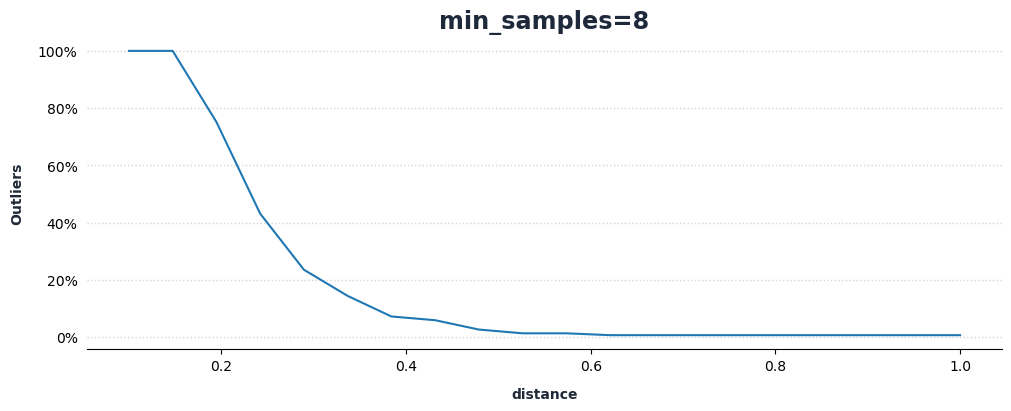

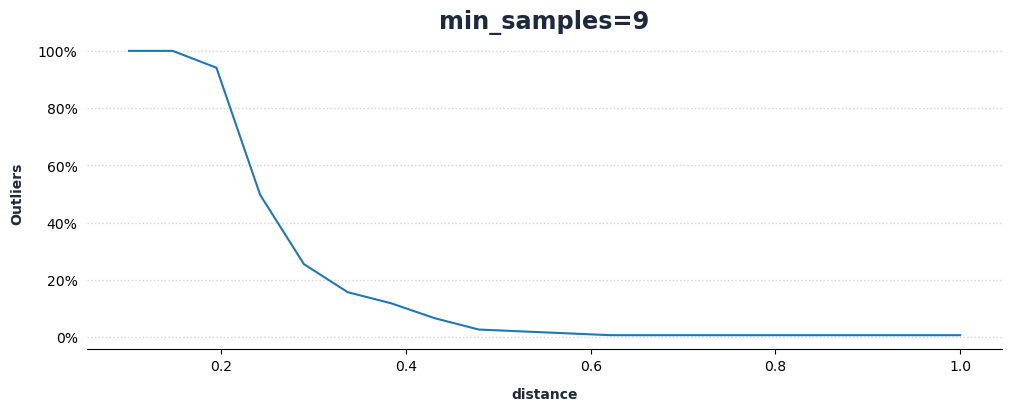

In [328]:
from matplotlib import ticker


for _, min_samples in enumerate(range(3, 10, 1)):
	fig, ax = plt.subplots(
		figsize=(10, 4),
		layout="constrained"
	)
	ax.set_title(
		f"min_samples={min_samples}",
		color="#1E293B",
		fontproperties=font_config["fig_title"]
	)

	ax.plot(distances, attempts[min_samples]["outliers"])
	ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1))
	ax.set_xlabel(
		"distance",
		fontdict=font_config["plot_label"],
		labelpad=10
	)
	ax.set_ylabel(
		"Outliers",
		fontdict=font_config["plot_label"],
		labelpad=10
	)
	ax.tick_params(axis="y", width=0)
	ax.grid(axis="y", color="#D4D4D4", linestyle="dotted", linewidth=1)
	ax.spines[["left", "right", "top"]].set_visible(False)
	plt.show()

Analizando las cantidad de muestras mínimas, las distancias y los outliers, los mejores parámetros parecen ser 	  	 `min_samples=4` y una distancia de entre 0.3 y 0.4.

#### Entrenamiento, visualización de resultados.

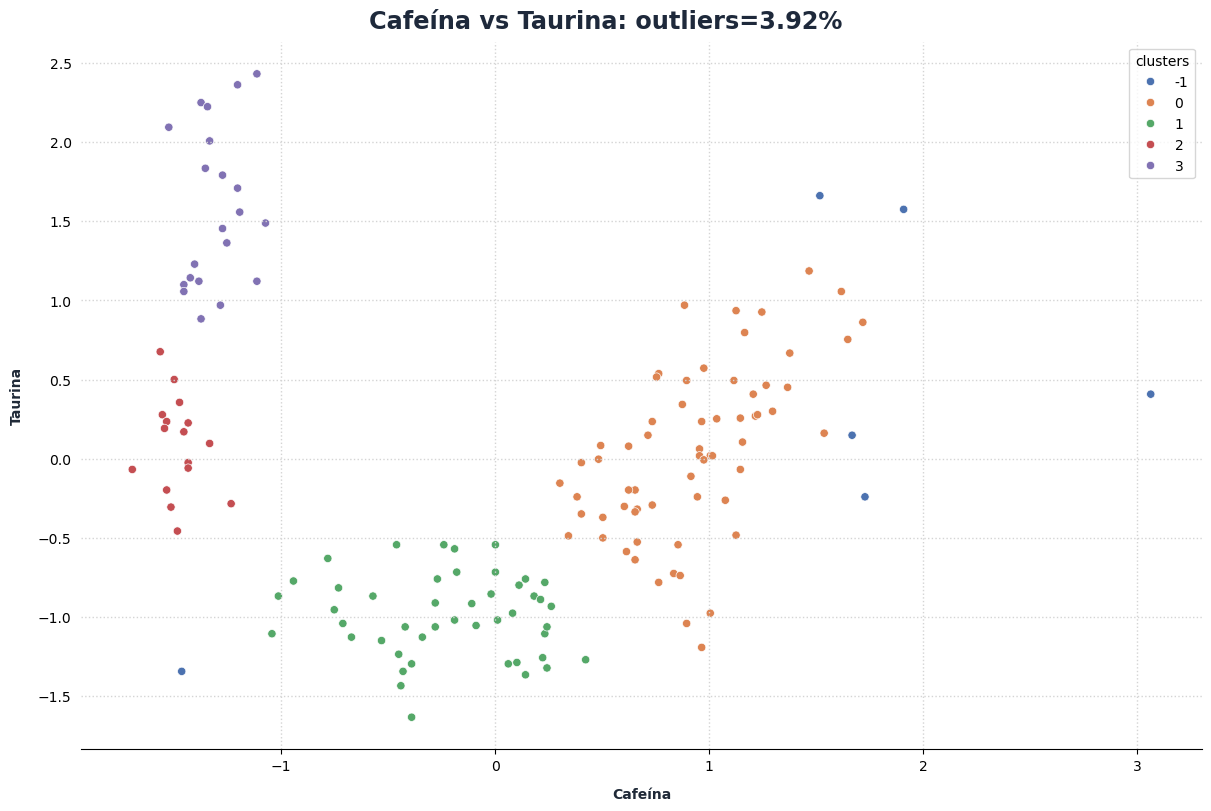

In [329]:
dbscan = DBSCAN(eps=.31, min_samples=4)
dbscan.fit(df_empowering_drinks[columns])
outliers = np.sum(dbscan.labels_ == -1) / len(dbscan.labels_)
df_empowering_drinks["clusters"] = dbscan.labels_


fig, ax = plt.subplots(figsize=(12, 8), layout="constrained")

fig.suptitle(
	f"Cafeína vs Taurina: outliers={ outliers * 100:.2f}%",
	color="#1E293B",
	fontproperties=font_config["fig_title"]
)
sns.scatterplot(
	x="Cafeína",
	y="Taurina",
	hue="clusters",
	palette="deep",
	data=df_empowering_drinks
)
ax.set_xlabel(
	"Cafeína",
	fontdict=font_config["plot_label"],
	labelpad=10
)
ax.set_ylabel(
	"Taurina",
	fontdict=font_config["plot_label"],
	labelpad=10
)
ax.tick_params(axis="y", width=0)
ax.grid(axis="both", color="#D4D4D4", linestyle="dotted", linewidth=1)
ax.spines[["left", "right", "top"]].set_visible(False)
plt.show()

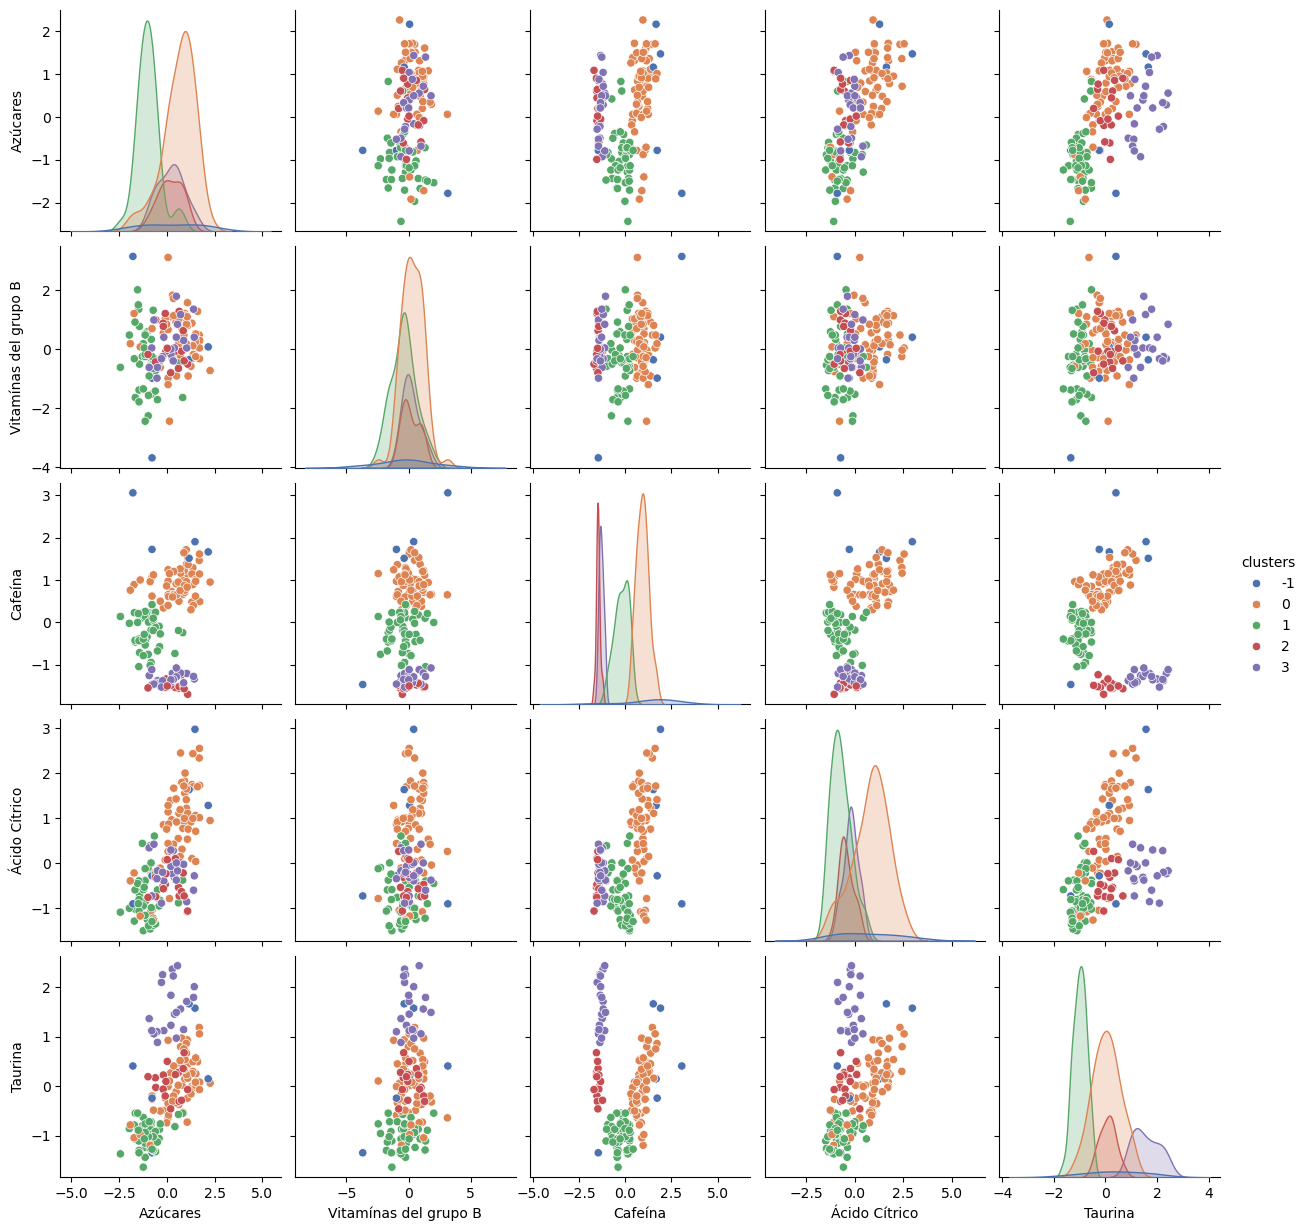

In [330]:
sns.pairplot(
	data=df_empowering_drinks,
	hue="clusters",
	palette="deep"
);

#### Jerárquico

In [331]:
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

Aplicamos dendrograma con el método `linkage ward`.

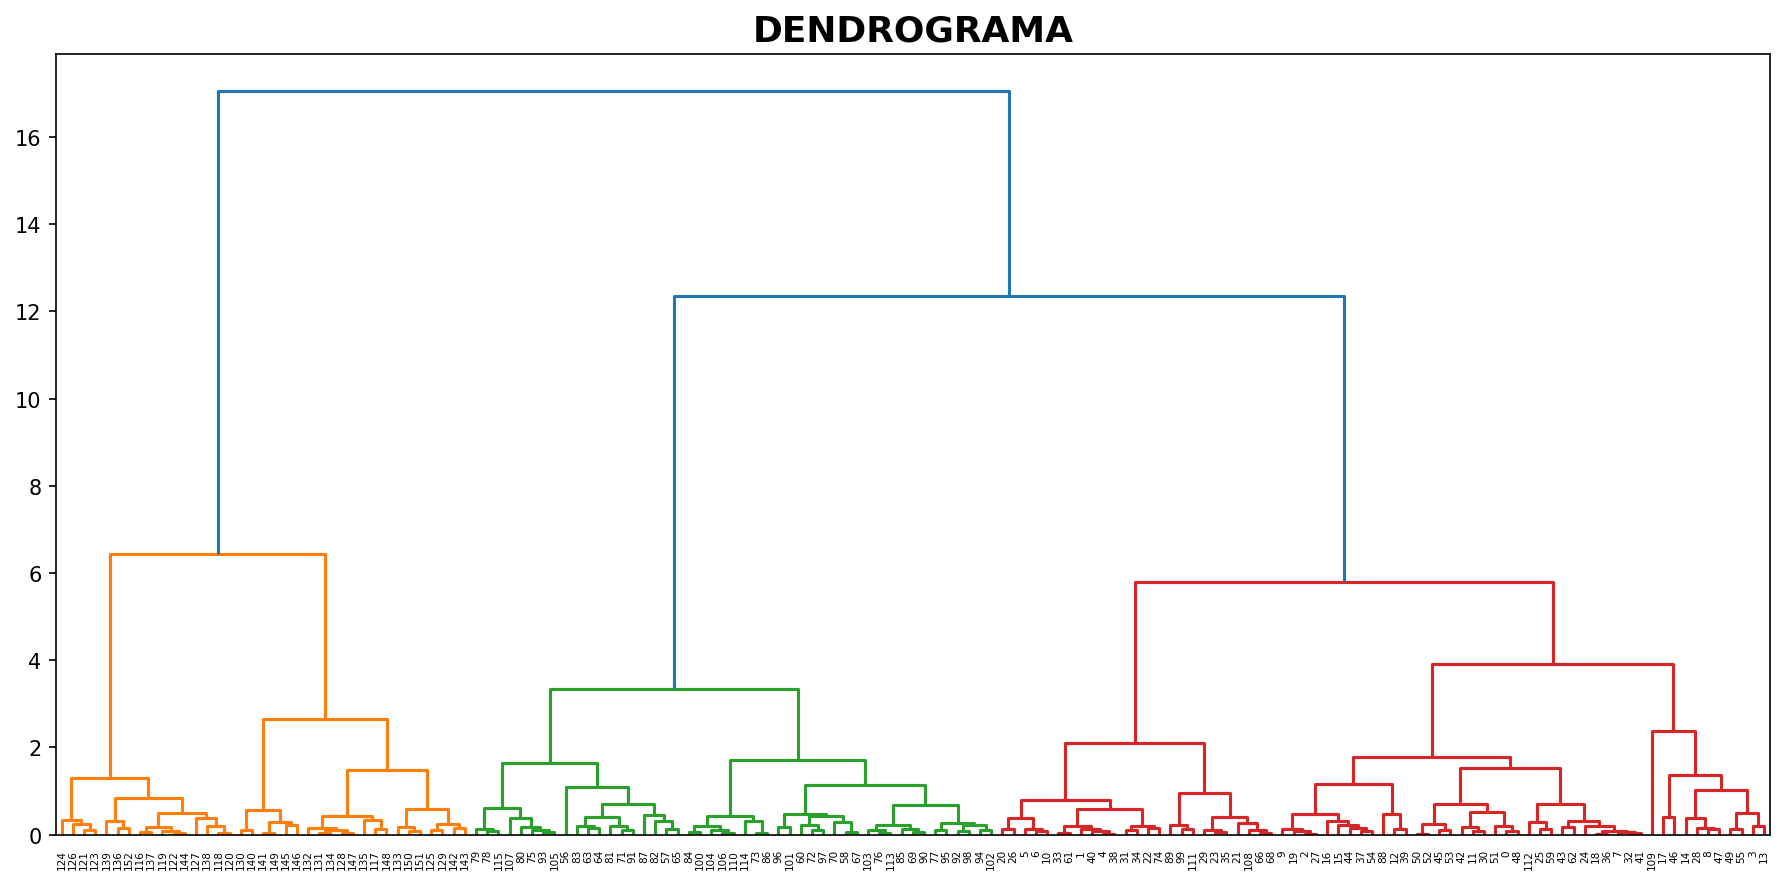

In [332]:
linkage_method = linkage(df_empowering_drinks[columns], method="ward")

plt.figure(dpi=150, figsize=(12, 6))
plt.title("DENDROGRAMA", fontdict=font_config["fig_title"])
dend = dendrogram(linkage_method)
#plt.xticks([])
plt.tight_layout()
plt.show()

Calculamos las distancias entre los clusters para identificar dónde se produce el mayor salto.

In [333]:
records = df_empowering_drinks[columns].shape[0]
distances = linkage_method[:, 2]
differences = np.diff(distances)
max_jump = np.argmax(differences)

clusters = records - max_jump - 1
print("Clusters:", clusters)

Clusters: 3


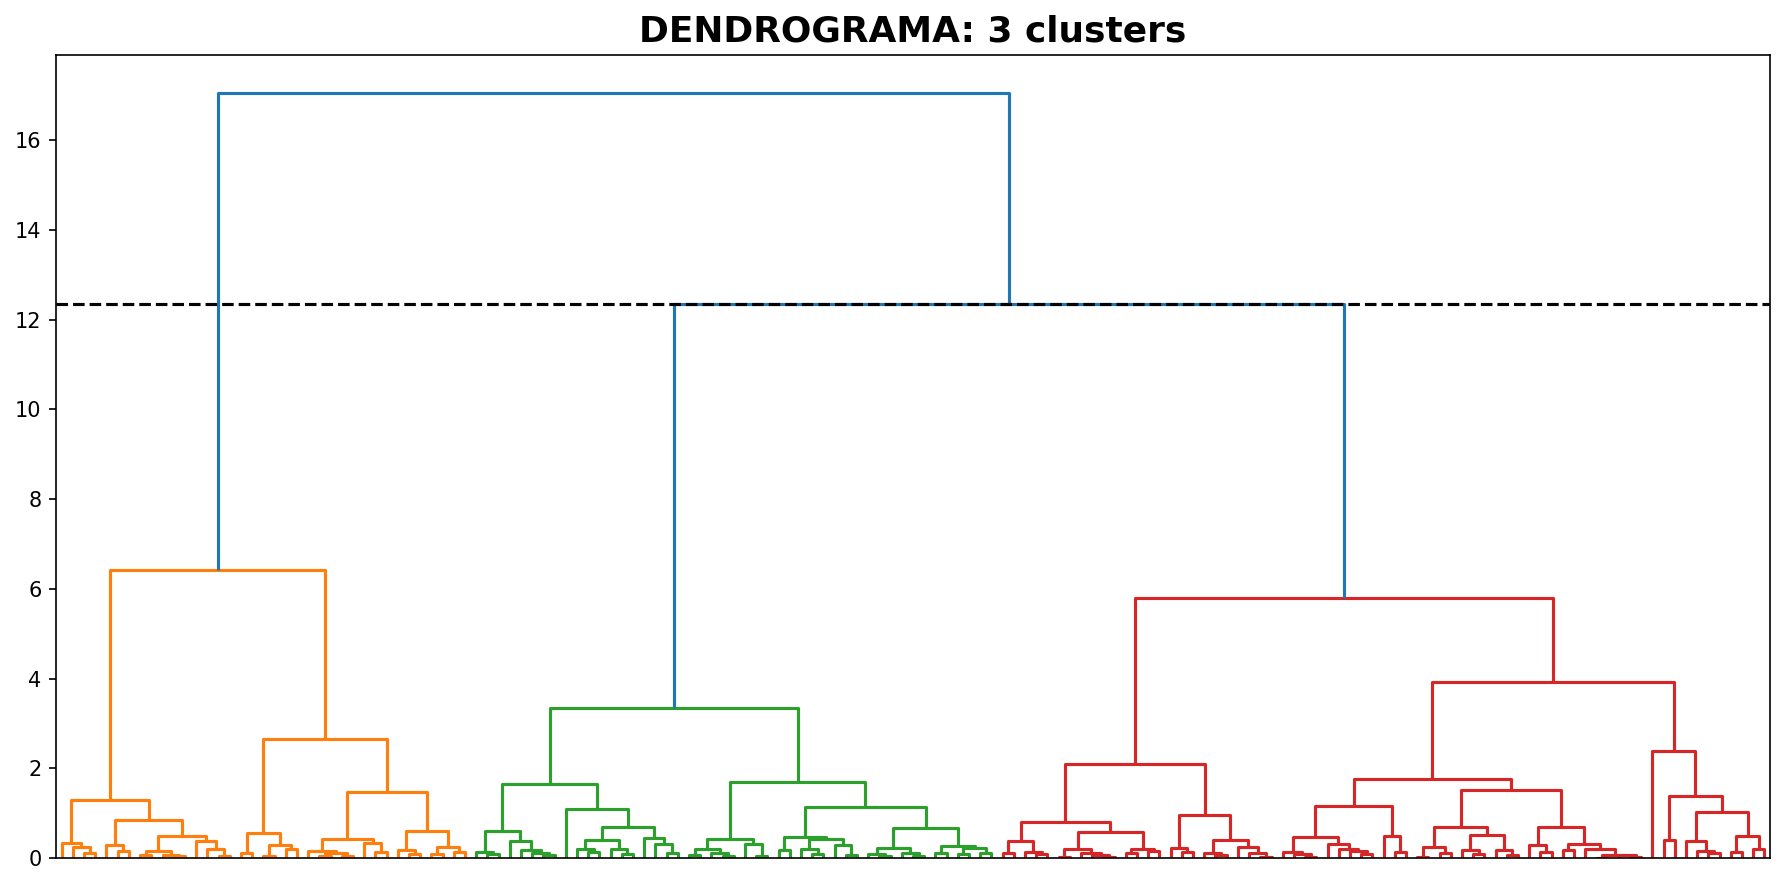

In [334]:
plt.figure(dpi=150, figsize=(12, 6))
plt.title(f"DENDROGRAMA: {clusters} clusters", fontdict=font_config["fig_title"])
dend = dendrogram(linkage_method)
plt.axhline(distances[max_jump + 1], color="#030303", linestyle="--")
plt.xticks([])
plt.tight_layout()
plt.show()

El dendrograma muestra un espacio amplio sin fusiones entre aproximadamente 7 y 12. Por ello, se eligió un corte a dicha altura para obteniendo tres clusters. En caso de ser necesaria una segmentación más detallada podríamos realizar el corte entre 6.2 y 5.7 aproximadamente.

In [335]:
df_agglomerative_clustering = df_empowering_drinks.copy()

In [336]:
agglomerative_clustering = AgglomerativeClustering(
	n_clusters=3,
	metric="euclidean",
	linkage="ward"
)
agglomerative_clustering.fit(df_empowering_drinks[columns])
df_agglomerative_clustering["clusters"] = agglomerative_clustering.labels_

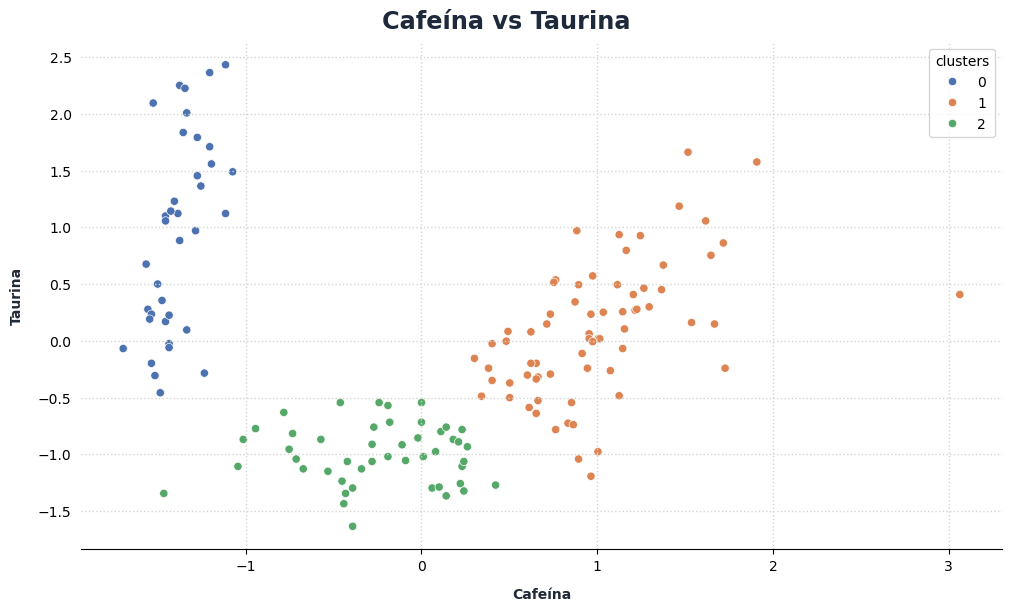

In [337]:
fig, ax = plt.subplots(figsize=(10, 6), layout="constrained")

fig.suptitle(
	"Cafeína vs Taurina",
	color="#1E293B",
	fontproperties=font_config["fig_title"]
)
sns.scatterplot(
	x="Cafeína",
	y="Taurina",
	hue="clusters",
	palette="deep",
	data=df_agglomerative_clustering
)
ax.set_xlabel(
	"Cafeína",
	fontdict=font_config["plot_label"],
	labelpad=10
)
ax.set_ylabel(
	"Taurina",
	fontdict=font_config["plot_label"],
	labelpad=10
)
ax.tick_params(axis="y", width=0)
ax.grid(axis="both", color="#D4D4D4", linestyle="dotted", linewidth=1)
ax.spines[["left", "right", "top"]].set_visible(False)
plt.show()

#### Discusión de los mismos

He optado por esta clusterización porque, en algunos casos, los elementos clasificados en los grupos dos y tres presentan valores muy distintos y no siguen un mismo patrón de comportamiento. Asimismo, se observa una reducción considerable de anomalías.

### Parte II: Nuevos experimentos

Los químicos están muy esperanzados con los modelos que les habéis mostrado y os pasan una lista de nuevos experimentos para que los clasifiquéis. Emplea uno de los modelos construidos, el que te resulte más sencillo, para segmentar los nuevos experimentos que puedes encontrar en *"./data/new_experiments.csv"*

In [338]:
df_experiments = pd.read_csv("./data/new_experiments.csv", sep="|")
df_experiments.head()

,Azúcares,Vitamínas del grupo B,Cafeína,Ácido Cítrico,Taurina
0,1.481555,0.305159,1.366128,2.239039,0.731870
1,0.616869,0.890014,0.583034,0.312420,-0.665332
2,-1.680724,0.341713,-0.340615,-0.213021,-0.976782
3,-0.284874,-1.412851,-0.782361,-1.193845,-0.717240
4,-0.927212,0.634140,-1.565455,-0.085641,-0.522583


In [339]:
df_experiments.info()

<class 'pandas.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Azúcares               6 non-null      float64
 1   Vitamínas del grupo B  6 non-null      float64
 2   Cafeína                6 non-null      float64
 3   Ácido Cítrico          6 non-null      float64
 4   Taurina                6 non-null      float64
dtypes: float64(5)
memory usage: 372.0 bytes


Podríamos realizar una unión de los datasets y rehacer la clasificación o construir un modelo predictivo clasificador `k-neighbors`, utilizando la columna que hemos creado, `clusters` como target, para realizar la clasificación de estos nuevos datos.

In [340]:
df_drinks = pd.concat([df_empowering_drinks, df_experiments], axis=0)
df_drinks.head()

,Azúcares,Vitamínas del grupo B,Cafeína,Ácido Cítrico,Taurina,clusters
0,1.518613,0.232053,1.034819,1.013009,0.251717,0.0
1,0.246290,-0.827996,0.733629,0.965242,-0.293321,0.0
2,0.196879,1.109334,1.215533,1.395148,0.269020,0.0
3,1.691550,0.487926,1.466525,2.334574,1.186068,0.0
4,0.295700,1.840403,0.663351,-0.037874,-0.319276,0.0


In [341]:
linkage_method = linkage(df_drinks[columns], method="ward")

records = df_drinks[columns].shape[0]
distances = linkage_method[:, 2]
diff = np.diff(distances)
max_jump = np.argmax(diff)

clusters = records - max_jump - 1
print("Clusters:", clusters)

Clusters: 3


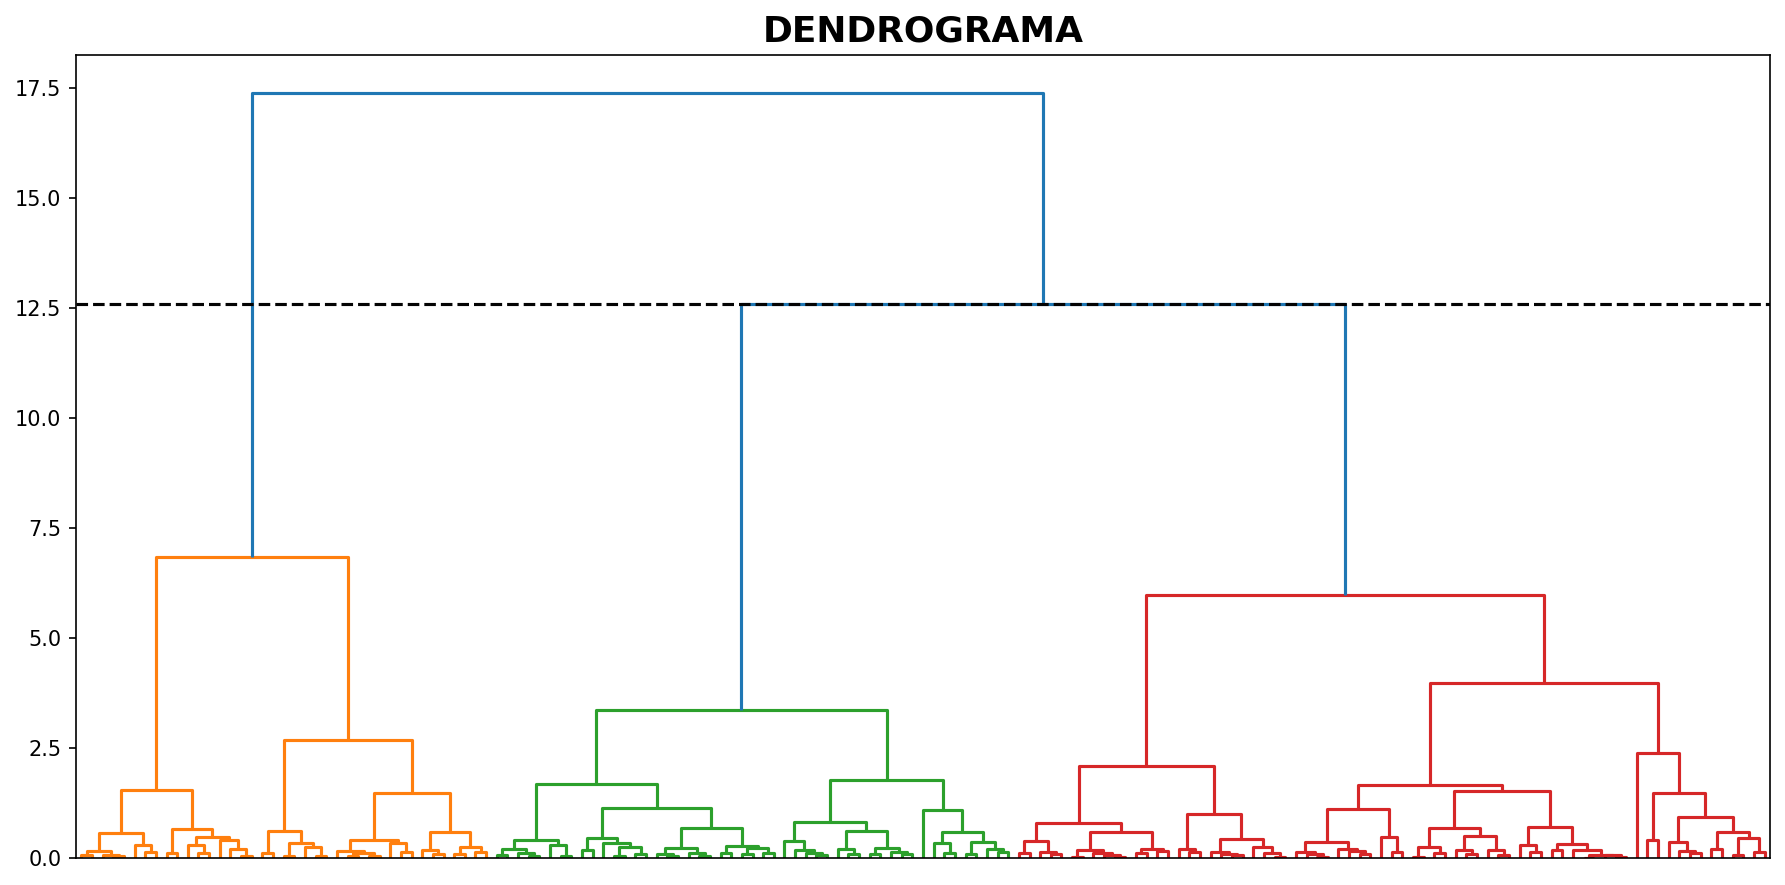

In [342]:
plt.figure(dpi=150, figsize=(12, 6))
plt.title("DENDROGRAMA", fontdict=font_config["fig_title"])
dend = dendrogram(linkage_method)
plt.axhline(distances[max_jump + 1], color="#030303", linestyle="--")
plt.xticks([])
plt.tight_layout()
plt.show()

Prácticamente no hay cambios en nuestro análisis previo.

In [343]:
agglomerative_clustering = AgglomerativeClustering(
	n_clusters=3,
	metric="euclidean",
	linkage="ward"
)
agglomerative_clustering.fit(df_drinks[columns])
df_drinks["clusters"] = agglomerative_clustering.labels_

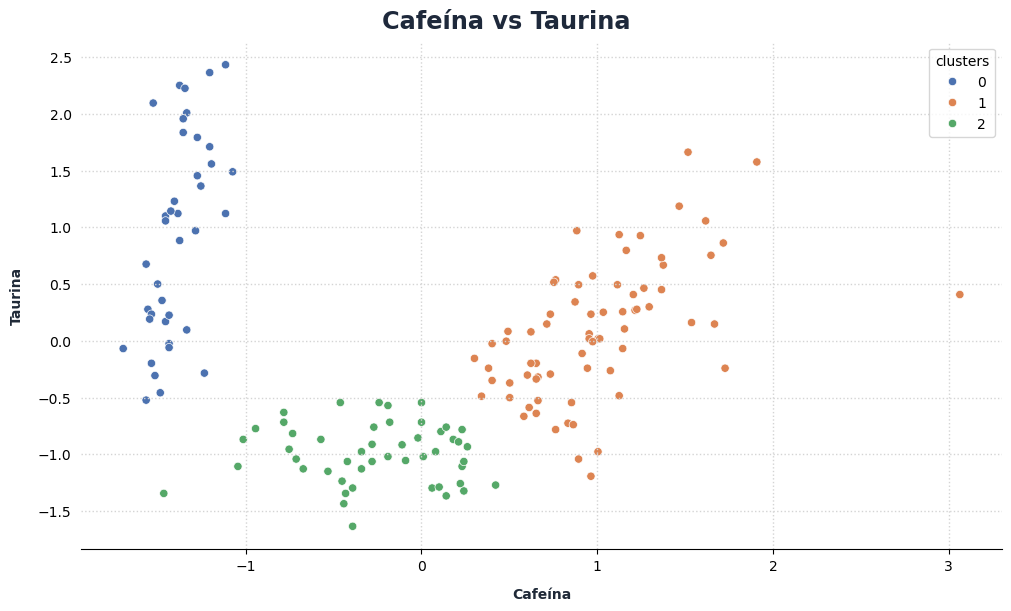

In [344]:
fig, ax = plt.subplots(figsize=(10, 6), layout="constrained")

fig.suptitle(
	"Cafeína vs Taurina",
	color="#1E293B",
	fontproperties=font_config["fig_title"]
)
sns.scatterplot(
	x="Cafeína",
	y="Taurina",
	hue="clusters",
	palette="deep",
	data=df_drinks
)
ax.set_xlabel(
	"Cafeína",
	fontdict=font_config["plot_label"],
	labelpad=10
)
ax.set_ylabel(
	"Taurina",
	fontdict=font_config["plot_label"],
	labelpad=10
)
ax.tick_params(axis="y", width=0)
ax.grid(axis="both", color="#D4D4D4", linestyle="dotted", linewidth=1)
ax.spines[["left", "right", "top"]].set_visible(False)
plt.show()

Podemos visualizar que los nuevos registros se han repartido equitativamente entre los tres clusters identificados.

In [351]:
df_drinks.tail(6)

,Azúcares,Vitamínas del grupo B,Cafeína,Ácido Cítrico,Taurina,clusters
0,1.481555,0.305159,1.366128,2.239039,0.731870,1
1,0.616869,0.890014,0.583034,0.312420,-0.665332,1
2,-1.680724,0.341713,-0.340615,-0.213021,-0.976782,2
3,-0.284874,-1.412851,-0.782361,-1.193845,-0.717240,2
4,-0.927212,0.634140,-1.565455,-0.085641,-0.522583,0
5,0.962743,-0.243142,-1.354622,-0.420013,1.956043,0


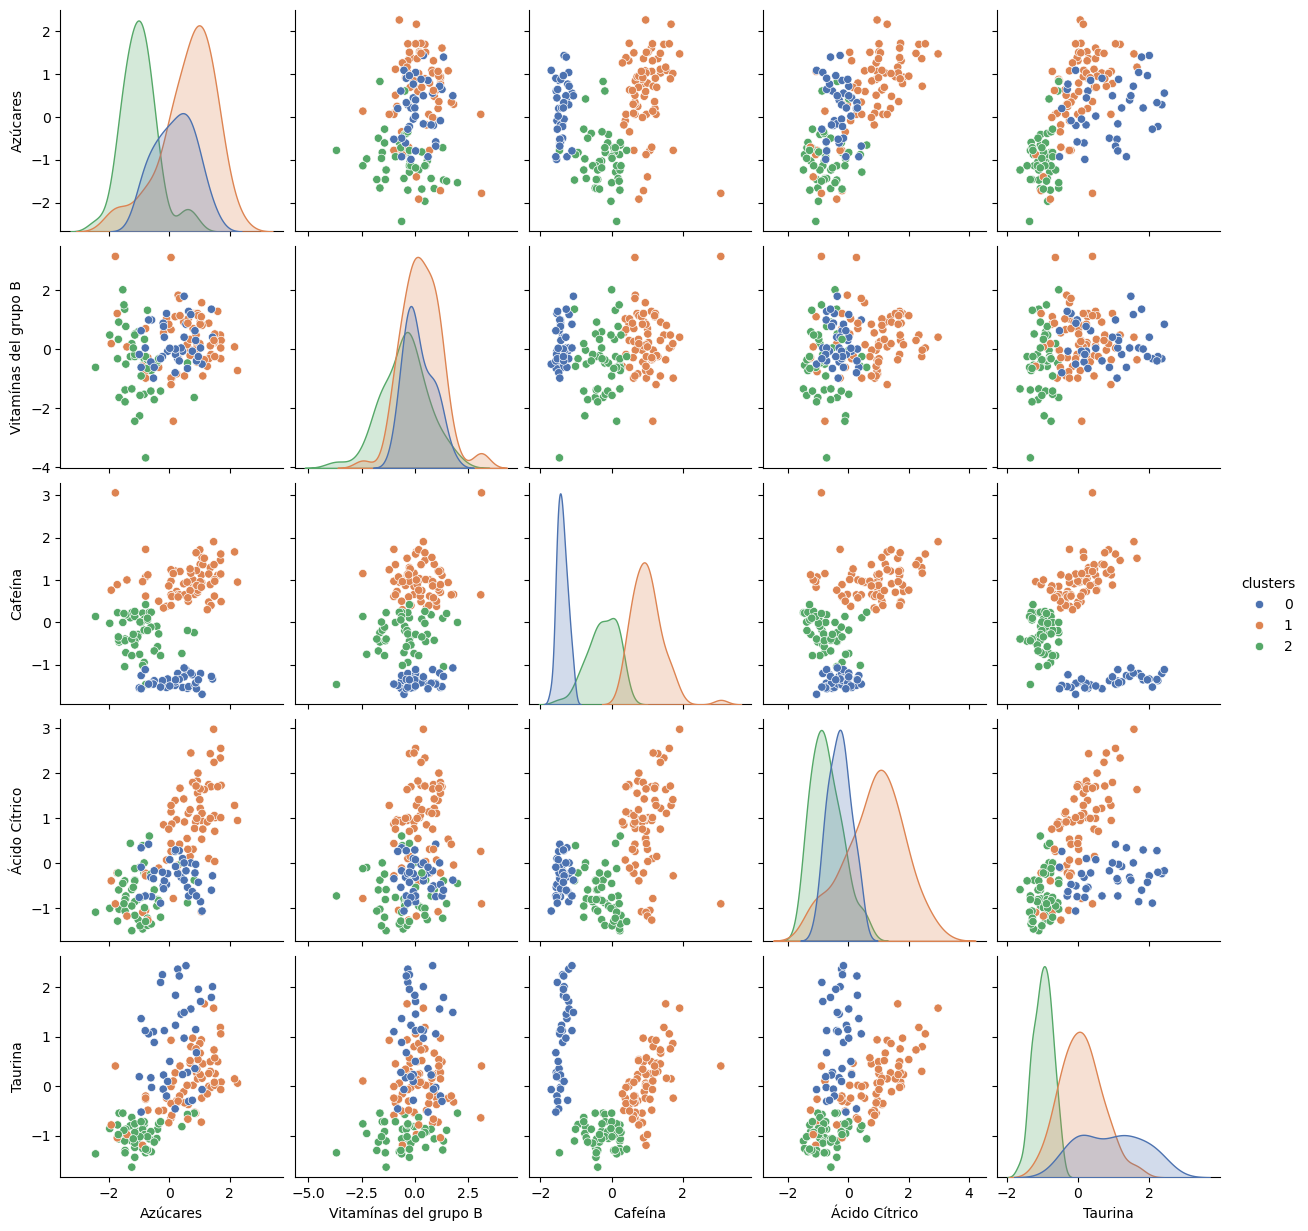

In [ ]:
sns.pairplot(
	data=df_drinks,
	hue="clusters",
	palette="deep"
);

### Parte III: EXTRA (Voluntario): 6 meses después...